# Clasificador de Géneros Musicales por Letra

Entrenamiento de un modelo de NLP para predecir el género musical de una canción a partir de su letra.

El notebook realiza lo siguiente:
1. Carga y limpieza del dataset (`songs_with_years_processed.csv`)
2. Preprocesamiento NLP (stopwords, stemming/lemmatización)
3. Vectorización TF-IDF + features lingüísticas
4. Entrenamiento y evaluación de múltiples modelos
5. Análisis de palabras clave por género
6. Predicción de nuevas letras

## 1. Instalación de dependencias

In [26]:
%pip install pandas numpy scikit-learn nltk matplotlib seaborn wordcloud joblib xgboost --quiet
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

Note: you may need to restart the kernel to use updated packages.


True

## 2. Imports

In [27]:
import re
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from wordcloud import WordCloud

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.preprocessing import LabelEncoder, StandardScaler

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost no disponible. Se omitirá de la comparación.")

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

RANDOM_STATE = 42

## 3. Carga y exploración del dataset

In [28]:
df = pd.read_csv("songs_with_years_processed.csv")

print(f"Shape: {df.shape}")
print(f"\nColumnas: {df.columns.tolist()}")
print(f"\nValores nulos:")
print(df.isnull().sum())
df.head(3)

Shape: (7933, 9)

Columnas: ['lyrics', 'artist_clean', 'genre_clean', 'word_count', 'song_norm', 'song', 'year', 'emocion_predominante_genero', 'top3_emociones_predominantes_genero']

Valores nulos:
lyrics                                 0
artist_clean                           0
genre_clean                            0
word_count                             0
song_norm                              0
song                                   0
year                                   0
emocion_predominante_genero            0
top3_emociones_predominantes_genero    0
dtype: int64


,lyrics,artist_clean,genre_clean,word_count,song_norm,song,year,emocion_predominante_genero,top3_emociones_predominantes_genero
0,"Hey you little Jesus' bride, why have you smil...",moonspell,Metal,197,let the children cum to me...,Let The Children Cum To Me...,2008,annoyance,"annoyance, approval, sadness"
1,"I am the moment, the soul\nThe moment that end...",moonspell,Metal,219,memento mori,Memento Mori,2020,annoyance,"annoyance, approval, sadness"
2,Vanishing act inside the weak\nIn need of you ...,moonspell,Metal,174,once it was ours!,Once It Was Ours!,2020,annoyance,"annoyance, approval, sadness"


In [29]:
if 'genre_clean' not in df.columns:
    raise ValueError("No se encontró la columna 'genre_clean' en el CSV.")

if 'lyrics' not in df.columns:
    raise ValueError("No se encontró la columna 'lyrics' en el CSV.")

print(f"Top 20 géneros:")
print(df['genre_clean'].value_counts().head(20).to_string())

Top 20 géneros:
genre_clean
Other                    2723
Metal                     884
Rock                      811
Hip Hop / Rap             664
Folk / Traditional        662
Pop                       654
Electronic / Dance        554
Country                   518
Latin                     119
R&B / Soul / Funk         115
Reggae / Caribbean         63
Blues                      63
Jazz                       39
Experimental               23
Punk / Emo / Hardcore      21
Classical / Art Music      20


## 4. Limpieza de etiquetas y filtrado

In [30]:
# Géneros válidos para el modelo
# Se excluyen: Other (datos muy variados/ruido), Folk/Traditional (señal léxica débil),
# y géneros con <120 muestras (Latin, R&B, Reggae, Blues, Jazz,
# Experimental, Punk, Classical) por datos insuficientes.

# Los valores de genre_clean usan estos nombres exactos:
GENEROS_VALIDOS = {
    'Metal',
    'Rock',
    'Hip Hop / Rap',
    'Pop',
    'Electronic / Dance',
    'Country',
}

# Descomentar si quisieramos limitar el mínimo y máximo de canciones por género
MIN_SAMPLES = 500
MAX_SAMPLES = 1000  

df_clean = df.dropna(subset=['lyrics', 'genre_clean']).copy()
df_clean['lyrics'] = df_clean['lyrics'].astype(str)
df_clean = df_clean[df_clean['lyrics'].str.len() > 50]

# Filtrar por los géneros seleccionados directamente sobre genre_clean
df_clean = df_clean[df_clean['genre_clean'].isin(GENEROS_VALIDOS)].copy()

# Usar genre_clean como etiqueta final (ya son nombres limpios y canónicos)
df_clean['genre'] = df_clean['genre_clean']

# Undersampling real por grupo
df_clean = (
    df_clean
    .groupby('genre', group_keys=False)
    .apply(lambda x: x.sample(min(len(x), MAX_SAMPLES), random_state=RANDOM_STATE))
    .reset_index(drop=True)
)

print(f"Canciones después del filtrado: {len(df_clean)}")
print(f"Géneros seleccionados ({df_clean['genre'].nunique()}):")
print(df_clean['genre'].value_counts().to_string())


Canciones después del filtrado: 4081
Géneros seleccionados (6):
genre
Metal                 883
Rock                  811
Hip Hop / Rap         663
Pop                   653
Electronic / Dance    553
Country               518


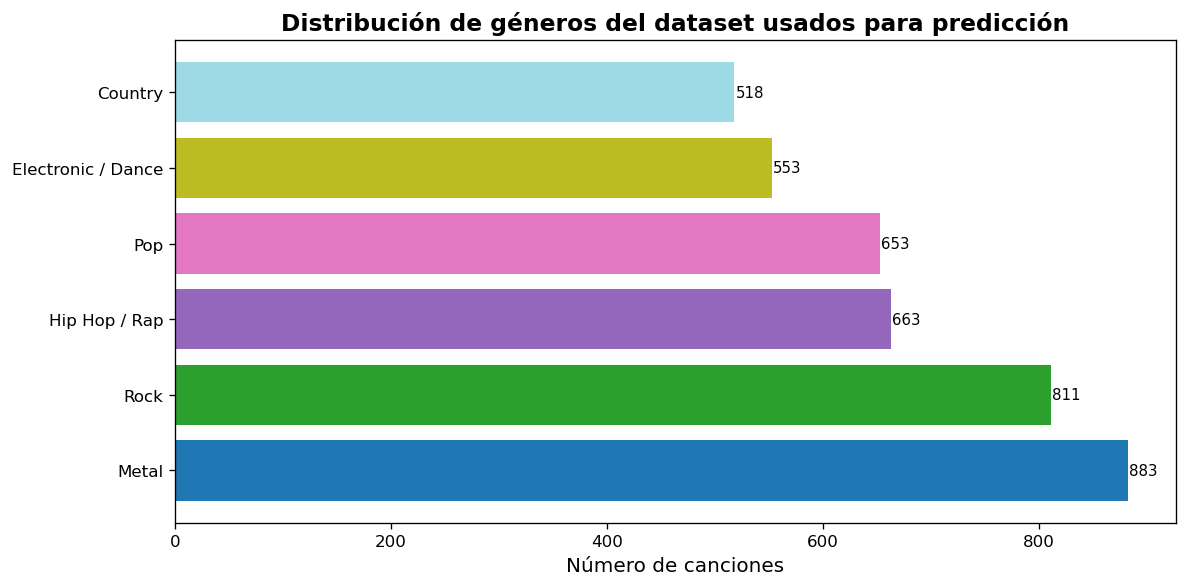

In [31]:
fig, ax = plt.subplots(figsize=(10, 5))
counts = df_clean['genre'].value_counts()
colors = plt.cm.tab20(np.linspace(0, 1, len(counts)))
bars = ax.barh(counts.index, counts.values, color=colors)
ax.set_xlabel('Número de canciones', fontsize=12)
ax.set_title('Distribución de géneros del dataset usados para predicción', fontsize=14, fontweight='bold')
for bar, val in zip(bars, counts.values):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 5. Preprocesamiento NLP

In [32]:
STOP_WORDS = set(stopwords.words('english'))
EXTRA_STOPS = {
    'oh', 'yeah', 'hey', 'la', 'na', 'da', 'ooh', 'ah',
    'gonna', 'wanna', 'gotta', 'could', 'would', 'got',
    'like', 'know', 'come', 'go', 'say', 'said', 'get',
    'verse', 'chorus', 'bridge', 'intro', 'outro',
    'repeat', 'x2', 'x3', 'x4',
}
STOP_WORDS |= EXTRA_STOPS

# Palabras básicas en inglés para la detección de idioma
ENGLISH_COMMON = {'the', 'and', 'you', 'that', 'was', 'for', 'are', 'with',
                  'his', 'they', 'this', 'have', 'from', 'but', 'not', 'she'}

lemmatizer = WordNetLemmatizer()

def preprocess(text: str) -> str:
    """Limpia y normaliza una letra:
       1. Minúsculas
       2. Elimina marcadores [Chorus], (x2), etc.
       3. Solo letras
       4. Elimina stopwords
       5. Lematiza
    """
    text = text.lower()
    text = re.sub(r'\[.*?\]|\(.*?\)', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(t)
        for t in tokens
        if t not in STOP_WORDS and len(t) > 2
    ]
    return ' '.join(tokens)


def is_likely_english(text: str, threshold: float = 0.03) -> bool:
    """Heurística rápida: comprueba si la letra contiene palabras inglesas comunes."""
    tokens = set(text.lower().split())
    overlap = tokens & ENGLISH_COMMON
    return len(overlap) / max(len(tokens), 1) >= threshold


print("Preprocesando letras...")
df_clean['lyrics_clean'] = df_clean['lyrics'].apply(preprocess)

# Features lingüísticas adicionales
df_clean['avg_word_length'] = df_clean['lyrics_clean'].apply(
    lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0
)
df_clean['unique_word_ratio'] = df_clean['lyrics_clean'].apply(
    lambda x: len(set(x.split())) / max(len(x.split()), 1)
)
df_clean['word_count'] = pd.to_numeric(
    df_clean.get('word_count', df_clean['lyrics_clean'].apply(lambda x: len(x.split()))),
    errors='coerce'
).fillna(0)

sample = df_clean.iloc[0]
print(f"\nCanción: {sample.get('song', 'N/A')} — {sample.get('artist_clean', 'N/A')}")
print(f"   Original (100 chars): {sample['lyrics'][:100]}...")
print(f"   Procesada (100 chars): {sample['lyrics_clean'][:100]}...")
print(f"   avg_word_length: {sample['avg_word_length']:.2f} | unique_word_ratio: {sample['unique_word_ratio']:.2f}")
print("\nPreprocesamiento completado")

Preprocesando letras...

Canción: The Baron — Johnny Cash
   Original (100 chars): Wish I had a-known ya

When you were a little younger

Around me you might have learned a thing or t...
   Procesada (100 chars): wish known little younger around might learned thing two known longer might little stronger maybe sh...
   avg_word_length: 5.24 | unique_word_ratio: 0.57

Preprocesamiento completado


## 6. División del dataset y vectorización TF-IDF

In [33]:
# Features: texto + variables numéricas lingüísticas
NUMERIC_FEATURES = ['word_count', 'avg_word_length', 'unique_word_ratio']

X = df_clean[['lyrics_clean'] + NUMERIC_FEATURES]
y = df_clean['genre']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# LabelEncoder para compatibilidad con XGBoost 
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc  = label_encoder.transform(y_test)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Clases ({len(label_encoder.classes_)}): {list(label_encoder.classes_)}")

Train: 3264 | Test: 817
Clases (6): ['Country', 'Electronic / Dance', 'Hip Hop / Rap', 'Metal', 'Pop', 'Rock']


## 7. Entrenamiento y comparación de modelos

In [34]:
# Transformadores por tipo de columna
text_transformer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=10000,
    min_df=5,
    max_df=0.8,
    sublinear_tf=True
)

numeric_transformer = StandardScaler(with_mean=False)  # sparse-safe

preprocessor = ColumnTransformer(
    transformers=[
        ('text', text_transformer, 'lyrics_clean'),
        ('num',  numeric_transformer, NUMERIC_FEATURES)
    ]
)

# Definición de modelos
models = {
    'Logistic Regression': LogisticRegression(
    C=1.0,              
    solver='saga',
    max_iter=2000,
    class_weight='balanced',
    multi_class='multinomial',
    random_state=RANDOM_STATE
    ),
    'Linear SVM': LinearSVC(
    C=0.5,             
    max_iter=5000,
    class_weight='balanced',
    random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', n_estimators=100,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
}

if XGBOOST_AVAILABLE:
    models['XGBoost'] = XGBClassifier(
        eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1
    )

results        = {}   # {name: {'accuracy': float, 'f1_macro': float, 'y_pred_enc': array}}
trained_models = {}   # {name: pipeline_entrenado}
best_model     = None
best_f1        = 0.0
best_name      = ""

print("Evaluando modelos con Texto (TF-IDF) + Features lingüísticas...\n")
print(f"{'Modelo':<25} {'Accuracy':<10} {'F1-macro':<10} {'Tiempo':>8}")
print("-" * 57)

for name, clf in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier',   clf)
    ])

    # logging de tiempo
    t0 = time.time()
    pipeline.fit(X_train, y_train_enc)
    elapsed = time.time() - t0

    y_pred_enc = pipeline.predict(X_test)

    acc = accuracy_score(y_test_enc, y_pred_enc)
    f1  = f1_score(y_test_enc, y_pred_enc, average='macro')

    print(f"{name:<25} {acc:.4f}     {f1:.4f}      {elapsed:6.1f}s")

    # Guardar resultados y pipeline entrenado
    results[name]        = {'accuracy': acc, 'f1_macro': f1, 'y_pred_enc': y_pred_enc}
    trained_models[name] = pipeline

    if f1 > best_f1:
        best_f1   = f1
        best_model = pipeline
        best_name  = name

print(f"\nMejor modelo seleccionado: {best_name} (F1-macro = {best_f1:.4f})")

Evaluando modelos con Texto (TF-IDF) + Features lingüísticas...

Modelo                    Accuracy   F1-macro     Tiempo
---------------------------------------------------------
Logistic Regression       0.4884     0.4720         5.0s
Linear SVM                0.4590     0.4376        17.3s
Random Forest             0.4162     0.3755         5.4s
XGBoost                   0.4259     0.3984        24.4s

Mejor modelo seleccionado: Logistic Regression (F1-macro = 0.4720)


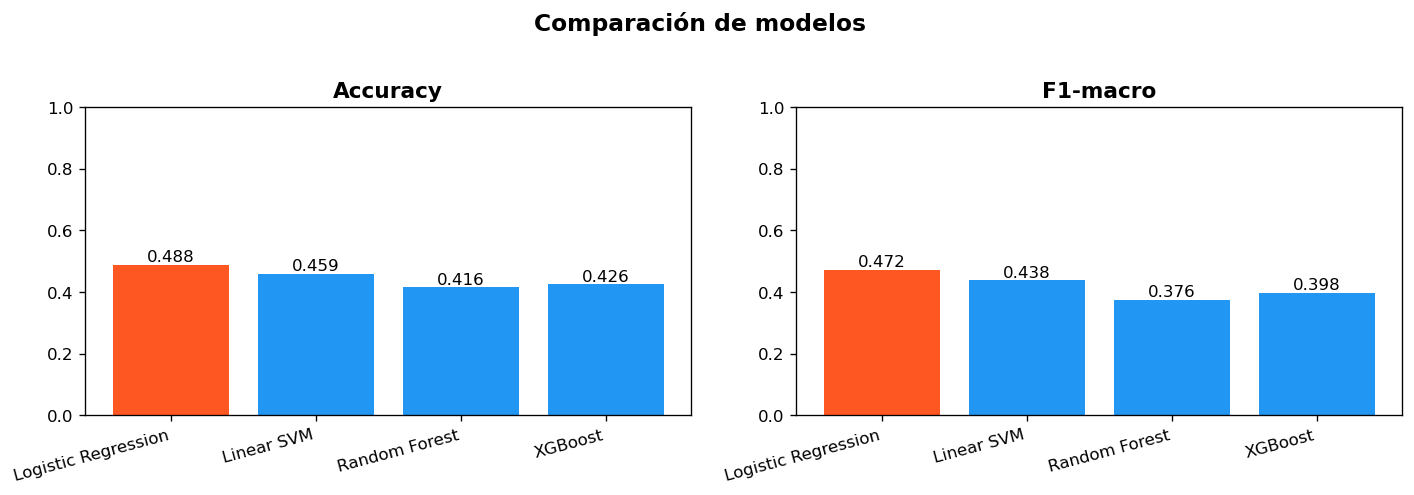

In [35]:
# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

names  = list(results.keys())
accs   = [results[n]['accuracy']  for n in names]
f1s    = [results[n]['f1_macro']  for n in names]
colors = ['#FF5722' if n == best_name else '#2196F3' for n in names]

for ax, vals, metric in zip(axes, [accs, f1s], ['Accuracy', 'F1-macro']):
    bars = ax.bar(names, vals, color=colors)
    ax.set_ylim(0, 1)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xticklabels(names, rotation=15, ha='right')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                f'{v:.3f}', ha='center', fontsize=10)

plt.suptitle('Comparación de modelos', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Evaluación detallada del mejor modelo

In [36]:
y_pred_enc_best = results[best_name]['y_pred_enc']
y_pred_best     = label_encoder.inverse_transform(y_pred_enc_best)

print(f"Resultados de clasificación por género usando {best_name}\n")
print(classification_report(y_test, y_pred_best, zero_division=0))

Resultados de clasificación por género usando Logistic Regression

                    precision    recall  f1-score   support

           Country       0.44      0.47      0.45       103
Electronic / Dance       0.27      0.30      0.28       111
     Hip Hop / Rap       0.78      0.82      0.80       133
             Metal       0.68      0.71      0.69       177
               Pop       0.29      0.30      0.29       131
              Rock       0.36      0.28      0.31       162

          accuracy                           0.49       817
         macro avg       0.47      0.48      0.47       817
      weighted avg       0.48      0.49      0.48       817



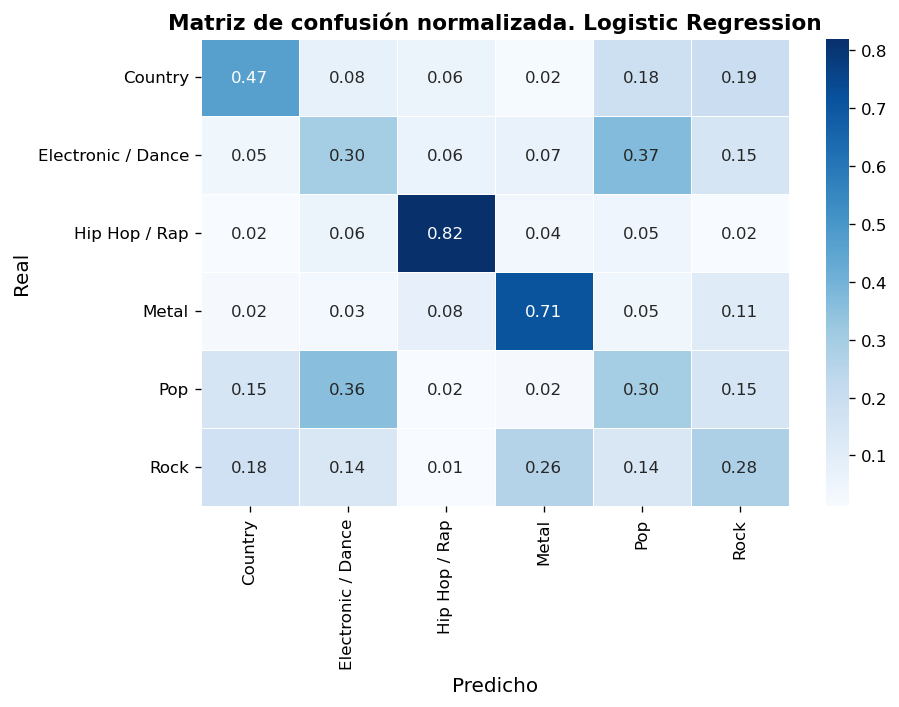

In [37]:
# Matriz de confusión
genres_sorted = sorted(y.unique())
cm_mat = confusion_matrix(y_test, y_pred_best, labels=genres_sorted, normalize='true')

fig, ax = plt.subplots(figsize=(max(8, len(genres_sorted)), max(6, len(genres_sorted))))
sns.heatmap(
    cm_mat, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=genres_sorted, yticklabels=genres_sorted,
    linewidths=0.5, ax=ax
)
ax.set_xlabel('Predicho', fontsize=12)
ax.set_ylabel('Real', fontsize=12)
ax.set_title(f'Matriz de confusión normalizada. {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Palabras clave por género

In [38]:
def get_top_features(clf, vectorizer, pipeline, genre_list, top_n=20):
    """Extrae las palabras con mayor peso para cada género.

    El ColumnTransformer concatena [TF-IDF (n_text) | numéricas (n_num)],
    por lo que coef_ y feature_importances_ tienen n_text + n_num columnas.
    Esta función recorta los coeficientes a solo la parte de texto antes
    de mapearlos a feature_names, evitando el IndexError original.

    Funciona con: LogisticRegression, LinearSVC (coef_), RandomForest (feature_importances_).
    """
    feature_names = np.array(vectorizer.get_feature_names_out())
    n_text        = len(feature_names)   # número de features de texto
    top_features  = {}

    if hasattr(clf, 'coef_'):
        coef    = clf.coef_
        classes = clf.classes_ if hasattr(clf, 'classes_') else list(range(len(genre_list)))
        for i, cls_idx in enumerate(classes):
            genre = label_encoder.inverse_transform([cls_idx])[0] if isinstance(cls_idx, (int, np.integer)) else cls_idx
            # Recortar a las primeras n_text columnas (solo TF-IDF)
            coef_text = coef[i][:n_text]
            idx       = np.argsort(coef_text)[::-1][:top_n]
            top_features[genre] = list(zip(feature_names[idx], coef_text[idx]))

    elif hasattr(clf, 'feature_importances_'):
        importances = clf.feature_importances_
        # Recortar a las primeras n_text columnas (solo TF-IDF)
        importances_text = importances[:n_text]
        idx = np.argsort(importances_text)[::-1][:top_n]
        for genre in genre_list:
            top_features[genre] = list(zip(feature_names[idx], importances_text[idx]))

    else:
        print(f"{type(clf).__name__} no expone coeficientes.")

    return top_features


# Extraer tfidf y clf desde el pipeline
tfidf      = best_model.named_steps['preprocessor'].named_transformers_['text']
clf_step   = best_model.named_steps['classifier']
genre_list = list(label_encoder.classes_)

top_features = get_top_features(clf_step, tfidf, best_model, genre_list, top_n=20)

if top_features:
    print(f"Top palabras por género extraídas ({len(top_features)} géneros)")
    sample_genre = list(top_features.keys())[0]
    print(f"\nEjemplo — {sample_genre}:")
    for word, score in top_features[sample_genre][:10]:
        print(f"   {word:<25} {score:.4f}")


Top palabras por género extraídas (6 géneros)

Ejemplo — Country:
   old                       2.7551
   well                      1.5183
   today                     1.4111
   blue                      1.3539
   born                      1.3355
   loved                     1.3117
   home                      1.3104
   darlin                    1.2673
   love                      1.2636
   sweet                     1.1741


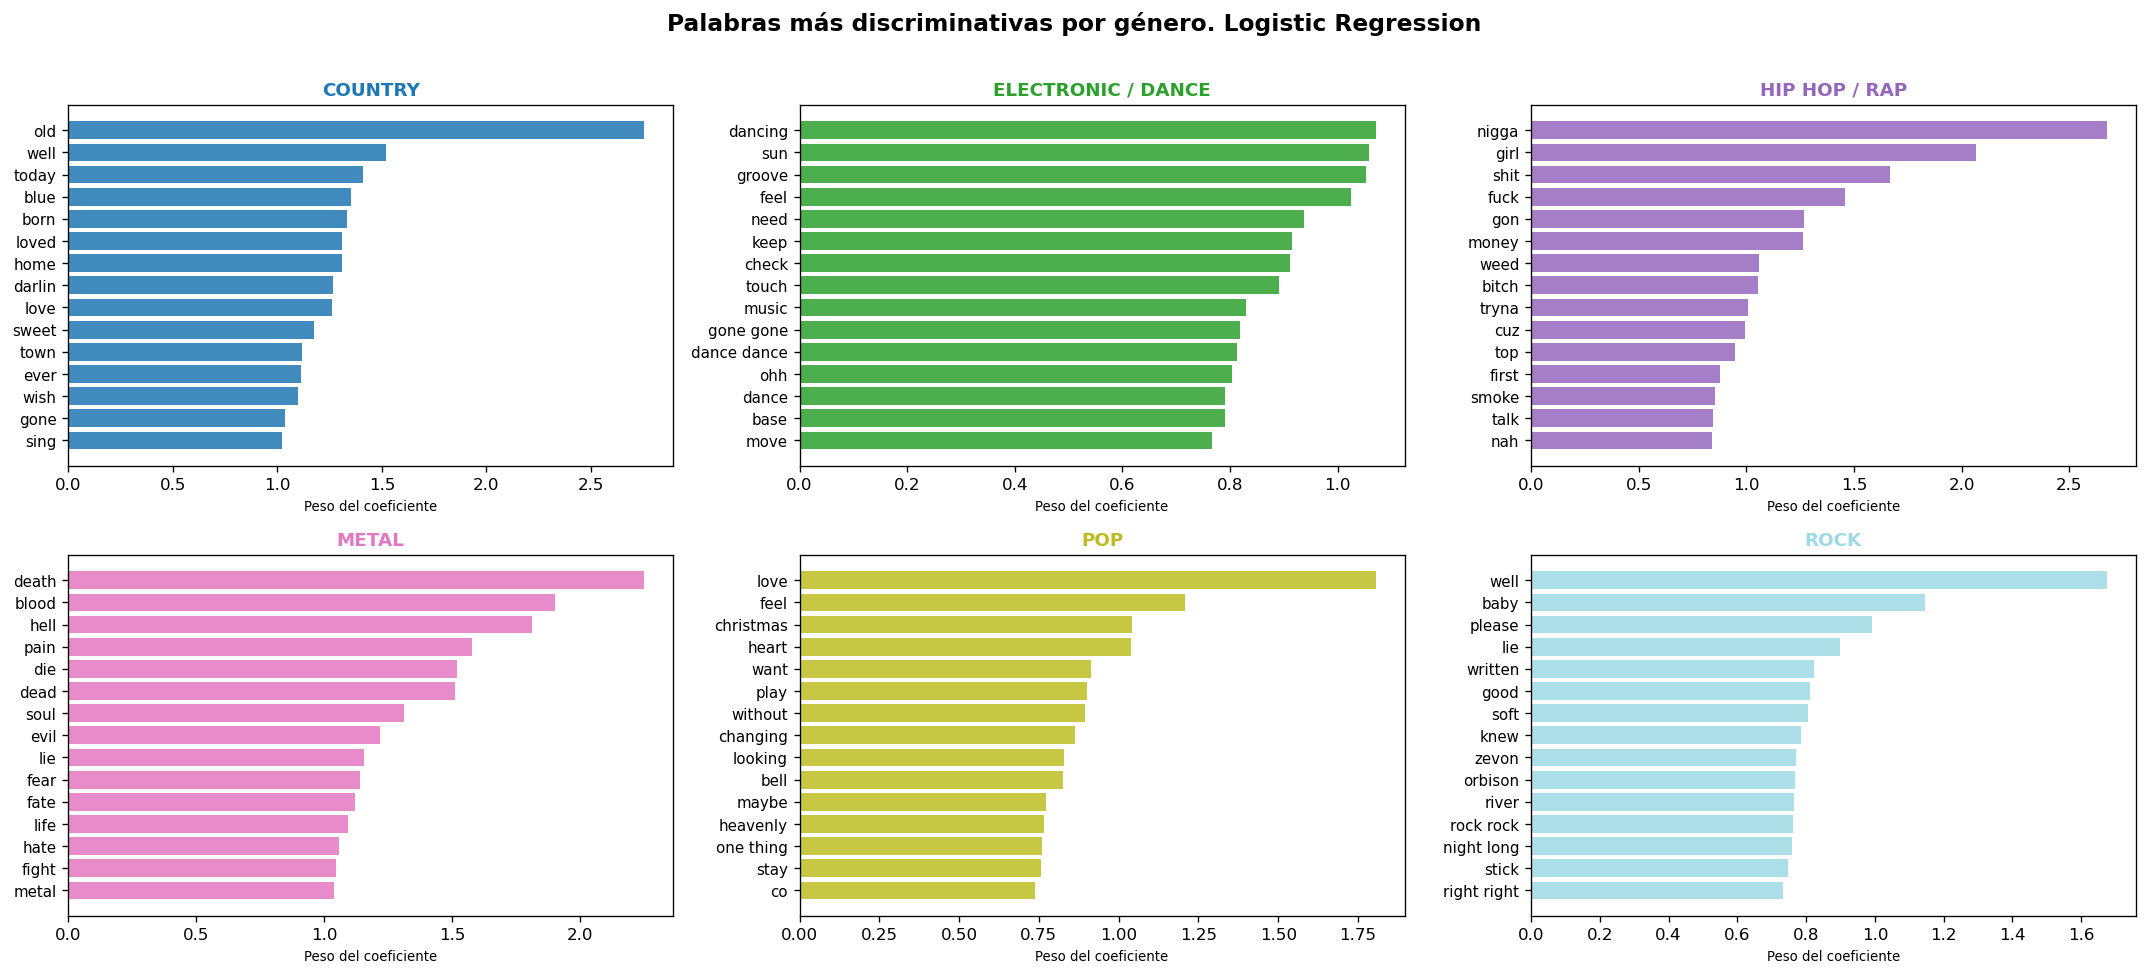

In [39]:
# Gráfico de barras: top palabras por género
if not top_features:
    print("No hay coeficientes disponibles para este modelo.")
else:
    genres_to_plot = list(top_features.keys())
    n_genres = len(genres_to_plot)
    ncols    = min(3, n_genres)
    nrows    = (n_genres + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
    axes      = np.array(axes).flatten()
    palette   = plt.cm.tab20(np.linspace(0, 1, n_genres))

    for ax, genre, color in zip(axes, genres_to_plot, palette):
        words, scores = zip(*top_features[genre][:15])
        y_pos = range(len(words))
        ax.barh(y_pos, scores, color=color, alpha=0.85)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(words, fontsize=9)
        ax.invert_yaxis()
        ax.set_title(genre.upper(), fontsize=11, fontweight='bold', color=color)
        ax.set_xlabel('Peso del coeficiente', fontsize=8)

    for ax in axes[n_genres:]:
        ax.axis('off')

    plt.suptitle(f'Palabras más discriminativas por género. {best_name}',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

## 10. Word Clouds por género

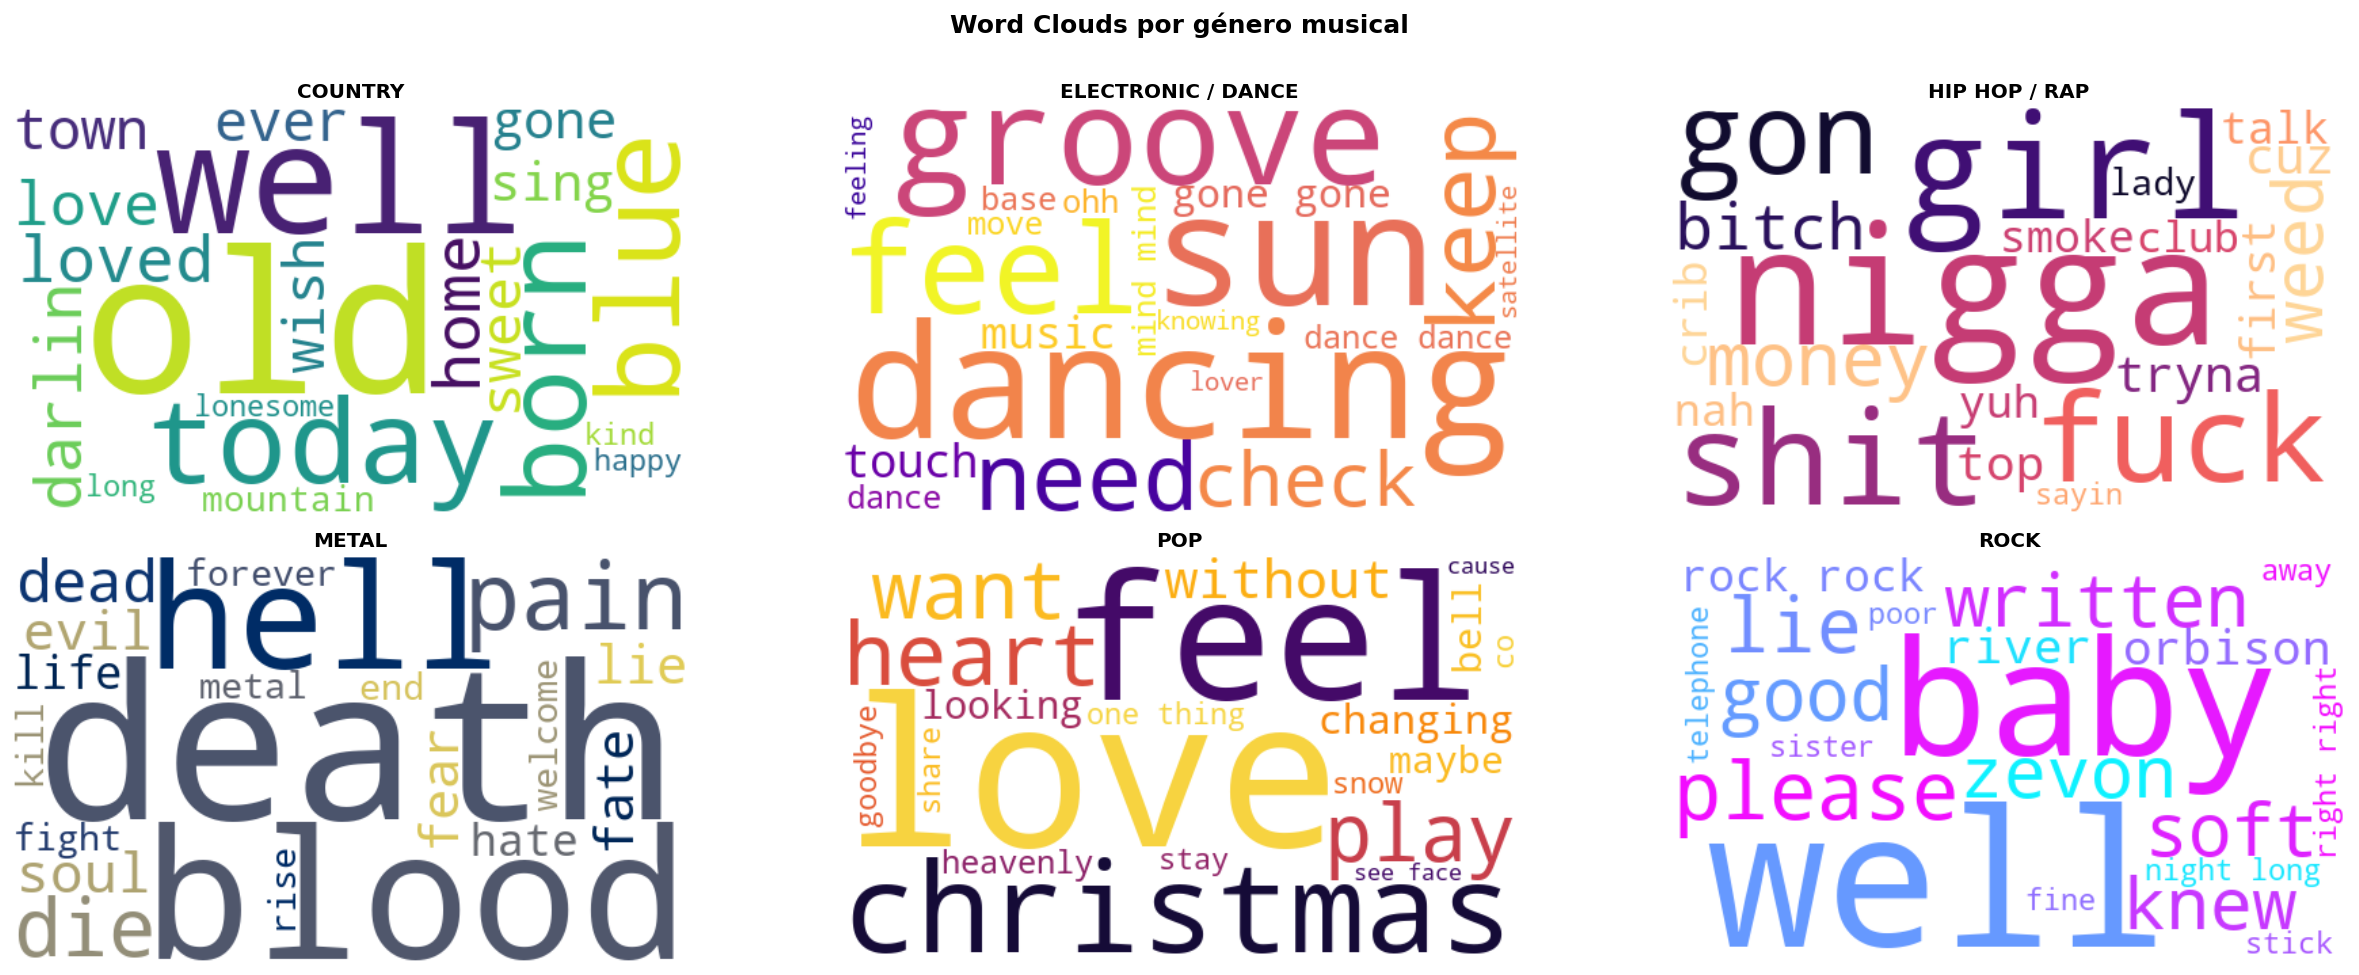

In [40]:
genres_wc = sorted(df_clean['genre'].unique())
n         = len(genres_wc)
ncols     = min(3, n)
nrows     = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4 * nrows))
axes      = np.array(axes).flatten()

train_index = set(X_train.index)

COLORMAPS = ['viridis', 'plasma', 'magma', 'cividis', 'inferno',
             'cool', 'summer', 'autumn', 'winter', 'copper']

for i, (ax, genre) in enumerate(zip(axes, genres_wc)):
    mask            = (df_clean['genre'] == genre) & (df_clean.index.isin(train_index))
    lyrics_for_genre = df_clean.loc[mask, 'lyrics_clean'].tolist()

    if not lyrics_for_genre:
        lyrics_for_genre = df_clean.loc[df_clean['genre'] == genre, 'lyrics_clean'].tolist()
    if not lyrics_for_genre:
        ax.axis('off')
        continue

    cmap = COLORMAPS[i % len(COLORMAPS)]

    if top_features and genre in top_features:
        freqs = {w: float(max(s, 1e-6)) for w, s in top_features[genre] if s > 0}
        if freqs:
            wc = WordCloud(width=500, height=300, background_color='white',
                           max_words=80, colormap=cmap).generate_from_frequencies(freqs)
        else:
            wc = WordCloud(width=500, height=300, background_color='white',
                           max_words=80, colormap=cmap,
                           stopwords=STOP_WORDS).generate(' '.join(lyrics_for_genre))
    else:
        wc = WordCloud(width=500, height=300, background_color='white',
                       max_words=80, colormap=cmap,
                       stopwords=STOP_WORDS).generate(' '.join(lyrics_for_genre))

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(genre.upper(), fontsize=12, fontweight='bold', pad=6)

for ax in axes[n:]:
    ax.axis('off')

plt.suptitle('Word Clouds por género musical', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 11. Análisis TF-IDF por género

In [41]:
# Muestra los términos con mayor TF-IDF medio para cada género.

print("Top términos TF-IDF por género (media sobre el corpus de entrenamiento)\n")

feature_names = tfidf.get_feature_names_out()
genre_tfidf   = {}

for genre in sorted(y.unique()):
    mask         = df_clean['genre'] == genre
    corpus_genre = df_clean.loc[mask, 'lyrics_clean']
    if len(corpus_genre) == 0:
        continue
    mat          = tfidf.transform(corpus_genre)
    mean_scores  = np.asarray(mat.mean(axis=0)).flatten()
    top_idx      = mean_scores.argsort()[::-1][:15]
    genre_tfidf[genre] = [(feature_names[i], mean_scores[i]) for i in top_idx]
    words = ', '.join(feature_names[i] for i in top_idx[:10])
    print(f"{genre.upper():<15}: {words}")

Top términos TF-IDF por género (media sobre el corpus de entrenamiento)

COUNTRY        : love, time, one, never, heart, way, old, cause, well, baby
ELECTRONIC / DANCE: love, feel, see, one, need, want, let, night, take, make
HIP HOP / RAP  : nigga, shit, bitch, fuck, cause, girl, see, back, make, man
METAL          : life, time, one, see, world, never, away, death, take, eye
POP            : love, feel, baby, let, want, heart, time, cause, never, see
ROCK           : love, time, baby, well, heart, way, one, see, night, let


## 12. Pipeline final y guardado del modelo

In [42]:
best_clf_only = clone(best_model.named_steps['classifier'])

# Preprocesador final con más features (reentrenamiento sobre todo el dataset)
text_transformer_final = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=30_000,
    min_df=3,
    sublinear_tf=True,
)

preprocessor_final = ColumnTransformer(
    transformers=[
        ('text', text_transformer_final, 'lyrics_clean'),
        ('num',  StandardScaler(with_mean=False), NUMERIC_FEATURES)
    ]
)

final_pipeline = Pipeline([
    ('preprocessor', preprocessor_final),
    ('classifier',   best_clf_only)
])

# Reentrenar sobre todo el dataset (train + test) con etiquetas codificadas
X_all   = df_clean[['lyrics_clean'] + NUMERIC_FEATURES]
y_all_enc = label_encoder.transform(df_clean['genre'])

print("Reentrenando el pipeline completo sobre todos los datos...")
final_pipeline.fit(X_all, y_all_enc)
print("Pipeline entrenado")

# Guarda pipeline + label_encoder juntos en un único archivo
MODEL_PATH = 'genre_classifier_full.pkl'
joblib.dump(
    {'pipeline': final_pipeline, 'label_encoder': label_encoder},
    MODEL_PATH
)
print(f"Modelo y LabelEncoder guardados en: {MODEL_PATH}")

Reentrenando el pipeline completo sobre todos los datos...
Pipeline entrenado
Modelo y LabelEncoder guardados en: genre_classifier_full.pkl


## 13. Predicción de nuevas letras

In [43]:
def predict_genre(
    lyrics: str,
    pipeline=None,
    le: LabelEncoder = None,
    model_path: str = 'genre_classifier_full.pkl',
    top_n: int = 3,
    verbose: bool = True
) -> dict:
    """
    Predice el género musical de una letra.

    Parameters
    ----------
    lyrics     : Texto de la letra.
    pipeline   : Pipeline ya cargado (opcional; si es None se carga del disco).
    le         : LabelEncoder ya cargado (opcional; si es None se carga del disco).
    model_path : Ruta al archivo .pkl guardado (dict con 'pipeline' y 'label_encoder').
    top_n      : Número de géneros candidatos a mostrar.
    verbose    : Si True, imprime el resultado formateado.

    Returns
    -------
    dict con 'genre' (str) y 'top_genres' (lista de tuplas (genre, prob)).
    """
    # Cargar desde disco si no se pasa pipeline
    if pipeline is None or le is None:
        saved = joblib.load(model_path)
        pipeline = saved['pipeline']
        le       = saved['label_encoder']

    # Advertencia de idioma ────────────────────────────────────────
    if not is_likely_english(lyrics):
        print("Advertencia: la letra puede no estar en inglés. "
              "La precisión puede ser menor.")

    # Preprocesar
    clean = preprocess(lyrics)

    # Construir DataFrame de entrada (igual que en entrenamiento)
    tokens = clean.split()
    X_input = pd.DataFrame([{
        'lyrics_clean':      clean,
        'word_count':        len(tokens),
        'avg_word_length':   np.mean([len(w) for w in tokens]) if tokens else 0,
        'unique_word_ratio': len(set(tokens)) / max(len(tokens), 1),
    }])

    # Predicción (codificada)
    genre_enc  = pipeline.predict(X_input)[0]
    genre_pred = le.inverse_transform([genre_enc])[0]

    # Probabilidades / scores -> decodificar índices con label_encoder
    top_genres = []
    clf        = pipeline.named_steps['classifier']
    X_vec      = pipeline.named_steps['preprocessor'].transform(X_input)

    if hasattr(clf, 'predict_proba'):
        probs = clf.predict_proba(X_vec)[0]
        for idx in np.argsort(probs)[::-1][:top_n]:
            top_genres.append((le.inverse_transform([idx])[0], float(probs[idx])))
    elif hasattr(clf, 'decision_function'):
        scores   = clf.decision_function(X_vec)[0]
        exp_s    = np.exp(scores - scores.max())
        probs_soft = exp_s / exp_s.sum()
        for idx in np.argsort(probs_soft)[::-1][:top_n]:
            top_genres.append((le.inverse_transform([idx])[0], float(probs_soft[idx])))
    else:
        top_genres = [(genre_pred, 1.0)]

    if verbose:
        print(f"\nGénero predicho: {genre_pred.upper()}")
        print("\nTop géneros candidatos:")
        for g, p in top_genres:
            bar = '█' * int(p * 30)
            print(f"   {g:<18} {bar:<30} {p*100:5.1f}%")

    return {'genre': genre_pred, 'top_genres': top_genres}

In [44]:
# Ejemplos de predicción

lyric_hiphop = """
I'm getting booked in Little Rock, Arkansas
New Haven, Connecticut, and places where they probably still fly the Confederate
I'm all alone in the United States of America
And who's, who's back at home takin' care of ya?
Bus rides, I'm counting LaQuintas out the window
Tough times, people love to act like we ain't been through those
The AC is broken, my hotel, it's hot as hell
Runnin' out of sodas, I might walk to Circle K by myself
Experimental drugs that don't help
I'm pourin' up a four by myself
Tunechi got some drank and I might help myself
I'll be home soon, least that's what I tell myself, until then

Don't let your friends turn you against
Me and convince you the time that we spent
Wasn't worth nothin', didn't mean what it meant
'Cause it did (it did)
It meant the world to me
It meant the world to me
It meant the world to me
Ayy

That bitch is so bold, she don't want my autograph
She don't even want my children, she just want a Audi
Or else she's a villain
That bitch got nerves on her
That bitch got curves on her
I'm out in the 'burbs, I'm out in the club lookin' for you
You ain't checkin' the word, no, I'm only checkin' for you, ayy, ayy
I'm missin' (missin', missin')
The long distance
Starts to feel like I'm dissin', dissin' you
Make me out be the villain 'cause it's killin' you
It hurts me too
Not seein' you

Don't let your friends turn you against
Me and convince you the time that we spent
Wasn't worth nothin', didn't mean what it meant
'Cause it did (it did, oh)
It meant the world to me
It meant the world to me
It meant the world to me
Baby
"""

print("-" * 55)
print("Ejemplo 1: Letra estilo hip-hop") # Fortworth de Drake
print("-" * 55)
result1 = predict_genre(lyric_hiphop, pipeline=final_pipeline, le=label_encoder)

lyric_rock = """
Buddy, you're a boy, make a big noise
Playing in the street, gonna be a big man someday
You got mud on your face, you big disgrace
Kicking your can all over the place

Singing
We will, we will rock you
We will, we will rock you

Buddy, you're a young man, hard man
Shouting in the street, gonna take on the world someday
You got blood on your face, you big disgrace
Waving your banner all over the place

We will, we will rock you
Sing it!
We will, we will rock you

Buddy, you're an old man, poor man
Pleading with your eyes, gonna make you some peace someday
You got mud on your face, you big disgrace
Somebody better put you back into your place

We will, we will rock you
Sing it!
We will, we will rock you

Everybody
We will, we will rock you
We will, we will rock you
"""

print("\n" + "-" * 55)
print("EJEMPLO 2: Letra estilo rock") # We will rock you de Queen
print("-" * 55)
result2 = predict_genre(lyric_rock, pipeline=final_pipeline, le=label_encoder)

-------------------------------------------------------
Ejemplo 1: Letra estilo hip-hop
-------------------------------------------------------

Género predicho: ROCK

Top géneros candidatos:
   Rock               ███████                         26.4%
   Country            ███████                         26.3%
   Hip Hop / Rap      ████                            15.0%

-------------------------------------------------------
EJEMPLO 2: Letra estilo rock
-------------------------------------------------------

Género predicho: ROCK

Top géneros candidatos:
   Rock               █████████████                   45.2%
   Country            █████                           19.0%
   Electronic / Dance ████                            14.9%


In [45]:
# Celda interactiva: introduce tu propia letra

MY_LYRICS = """
Escribe aquí tu letra...
Puede ser en inglés o en español.
Cuantos más versos, mejor predicción.
"""

if MY_LYRICS.strip() and 'Escribe aquí' not in MY_LYRICS:
    print("-" * 55)
    print("TU LETRA")
    print("-" * 55)
    predict_genre(MY_LYRICS, pipeline=final_pipeline, le=label_encoder)
else:
    print("Reemplaza MY_LYRICS con el texto de tu canción y vuelve a ejecutar.")

Reemplaza MY_LYRICS con el texto de tu canción y vuelve a ejecutar.


## 14. Validación cruzada del mejor modelo

In [46]:
print(f"Validación cruzada (5-fold) del mejor modelo: {best_name}")
print("Esto puede tardar unos minutos...\n")

cv_text_transformer = TfidfVectorizer(
    ngram_range=(1, 2), max_features=30_000, min_df=3, sublinear_tf=True
)
cv_preprocessor = ColumnTransformer(
    transformers=[
        ('text', cv_text_transformer, 'lyrics_clean'),
        ('num',  StandardScaler(with_mean=False), NUMERIC_FEATURES)
    ]
)

cv_pipeline = Pipeline([
    ('preprocessor', cv_preprocessor),
    ('classifier',   clone(best_model.named_steps['classifier']))  # solo el clf
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_acc = cross_val_score(
    cv_pipeline, X_all, y_all_enc,
    cv=skf, scoring='accuracy', n_jobs=1
)
cv_f1 = cross_val_score(
    cv_pipeline, X_all, y_all_enc,
    cv=skf, scoring='f1_macro', n_jobs=1
)

print(f"  Accuracy  por fold: {[f'{v:.4f}' for v in cv_acc]}")
print(f"  Accuracy  media:    {cv_acc.mean():.4f} ± {cv_acc.std():.4f}")
print(f"\n  F1-macro  por fold: {[f'{v:.4f}' for v in cv_f1]}")
print(f"  F1-macro  media:    {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")

Validación cruzada (5-fold) del mejor modelo: Logistic Regression
Esto puede tardar unos minutos...

  Accuracy  por fold: ['0.4357', '0.4620', '0.4828', '0.4657', '0.4485']
  Accuracy  media:    0.4590 ± 0.0160

  F1-macro  por fold: ['0.4112', '0.4465', '0.4689', '0.4529', '0.4324']
  F1-macro  media:    0.4424 ± 0.0195


## 15. Carga rápida del modelo guardado (para producción)

In [47]:
# Ejemplo de uso standalone: cargar el modelo y predecir sin reentrenar.
# El archivo .pkl contiene tanto el pipeline como el label_encoder.

saved = joblib.load('genre_classifier_full.pkl')
loaded_pipeline = saved['pipeline']
loaded_le       = saved['label_encoder']
print("Modelo y LabelEncoder cargados desde disco")
print(f"Géneros disponibles: {list(loaded_le.classes_)}")

test_lyrics = """
I walk a lonely road the only one that I have ever known
Don't know where it goes but it's home to me and I walk alone
My shadow's the only one that walks beside me
My shallow heart's the only thing that's beating
"""

predict_genre(test_lyrics, pipeline=loaded_pipeline, le=loaded_le)

Modelo y LabelEncoder cargados desde disco
Géneros disponibles: ['Country', 'Electronic / Dance', 'Hip Hop / Rap', 'Metal', 'Pop', 'Rock']

Género predicho: COUNTRY

Top géneros candidatos:
   Country            █████████                       33.2%
   Rock               ███████                         26.4%
   Metal              █████                           18.2%


{'genre': 'Country',
 'top_genres': [('Country', 0.3316413931793696),
  ('Rock', 0.26405412532258965),
  ('Metal', 0.18182458459581052)]}